# BD3LMs
D3PM의 확장 버전입니다.

D3PM은 주어진 시퀀스에 대해 한번에 디퓨전을 진행하여 모든 토큰을 지정해둔 timestep만큼 denoising 과정을 거쳐 복구했습니다.

이는 나쁘지 않고, GPU 구조의 병렬화를 고려해보면 꽤나 효율적이겠지만, 순서대로 생성하지 않기에 부족한 점이 있습니다.



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
import math
class TimeStepEmbedder(nn.Module):
    def __init__(self, freq_size, hidden_size):
        super(TimeStepEmbedder, self).__init__()
        self.learnable_transformation = nn.Sequential(
            nn.Linear(freq_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.freq_size = freq_size

    def get_sinusoidal(self, t, dim, theta = 10000):
        half = dim // 2
        freqs = torch.exp(
            -math.log(theta) * torch.arange(start = 0, end=half, device=t.device) / half
        )
        args = t[:, None] * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

        return embedding

    def forward(self, t):
        t_freq = self.get_sinusoidal(t, self.freq_size).to(dtype = next(self.parameters()).dtype)
        t_emb = self.learnable_transformation(t_freq)
        return t_emb

In [3]:
def get_cosine_schedule(timesteps, s = 0.008):
    t = torch.arange(timesteps+1, dtype=torch.float32)
    alpha_bar = torch.cos(((t / timesteps) + s) * torch.pi / 2) ** 2
    alpha_bar = alpha_bar / alpha_bar[0]
    return alpha_bar

In [4]:
def q_sample(x_0, t, alphas_cumprod, mask_token_id, device):
    """
    :param x_0: 임의 길이의 토큰 시퀀스
    :param t: 타임스텝 값
    :param alphas_cumprod: t 번째 alpha의 cumprod 구한 거 넘겨주셔야 함. 스케줄 값 접근한거.
    :param mask_token_id: 맨 마지막 토큰. [MASK].
    :return:
    """
    # t에 해당하는 alpha_cumprod (스케줄링에서 이미 사실상 구한거). (B, 1, 1, ...) 형태로 브로드캐스팅 준비
    alpha_bar_t = alphas_cumprod[t].view(-1, 1).to(device)

    # 각 위치마다 MASK로 바꿀지 결정하는 마스크 생성
    # torch.rand_like는 매번 다른 난수를 생성, 이를 원래라면 훈련 루프에서 관리해 줘야 함
    rand_mask = torch.rand_like(x_0, device=device, dtype=torch.float32) > alpha_bar_t

    mask_token = torch.full_like(x_0, fill_value=mask_token_id)
    # rand_mask가 True인 위치는 MASK 토큰으로, False인 위치는 원래 토큰 x_0으로
    x_t = torch.where(rand_mask, mask_token, x_0)

    return x_t

In [5]:
from rotary_embedding_torch import RotaryEmbedding
from einops import rearrange, einsum
from einops.layers.torch import Rearrange
from typing import Optional, Tuple

class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, heads):
        super().__init__()
        self.heads = heads
        self.head_dim = hidden_size // heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(hidden_size, hidden_size)
        self.k_proj = nn.Linear(hidden_size, hidden_size)
        self.v_proj = nn.Linear(hidden_size, hidden_size)
        self.out_proj = nn.Linear(hidden_size, hidden_size)

        self.pos_emb = RotaryEmbedding(dim=self.head_dim)
        self.split_heads = Rearrange('b n (h d) -> b h n d', h = heads)

    def forward(self,
                x: torch.Tensor,
                past_kv: Optional[Tuple[torch.Tensor, torch.Tensor]] = None,
                attn_mask: Optional[torch.Tensor] = None):

        B, N_q, _ = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q, k, v = map(self.split_heads, (q, k, v))

        # KV 캐시 처리
        if past_kv is not None:
            k_cache, v_cache = past_kv
            k = torch.cat([k_cache, k], dim=2)
            v = torch.cat([v_cache, v], dim=2)

        present_kv = (k, v) # 뉴 캐시!!

        seq_start_pos = past_kv[0].shape[2] if past_kv is not None else 0
        q = self.pos_emb.rotate_queries_or_keys(q, offset=seq_start_pos)
        k = self.pos_emb.rotate_queries_or_keys(k)

        sim = einsum(q, k, 'b h q_len d, b h k_len d -> b h q_len k_len') * self.scale

        if attn_mask is not None:
            sim = sim + attn_mask

        attn = sim.softmax(dim=-1)

        ctx = einsum(attn, v, 'b h q_len k_len, b h k_len d -> b h q_len d')
        attn_out = rearrange(ctx, 'b h n d -> b n (h d)')

        return self.out_proj(attn_out), present_kv

class TransformerBlock(nn.Module):
    def __init__(self, hidden_size, heads, ffn_size):
        super().__init__()
        self.attn = MultiHeadAttention(hidden_size, heads)
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, ffn_size),
            nn.GELU(),
            nn.Linear(ffn_size, hidden_size)
        )
        self.norm1 = nn.RMSNorm(hidden_size)
        self.norm2 = nn.RMSNorm(hidden_size)

    def forward(self,
                x: torch.Tensor,
                past_kv: tuple[torch.Tensor, torch.Tensor] | None= None,
                attn_mask: torch.Tensor | None = None
               ) -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        normed_x = self.norm1(x)
        attn_output, present_kv = self.attn(normed_x, past_kv=past_kv, attn_mask=attn_mask)
        x = x + attn_output
        x = x + self.ffn(self.norm2(x))

        return x, present_kv

In [73]:
from torch.nn.attention.flex_attention import create_block_mask, BlockMask

def create_causal_mask(seq_len: int, device: torch.device):
    mask = torch.ones(seq_len, seq_len, device=device, dtype=torch.bool).tril(diagonal=0)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, 0.0)
    return mask.unsqueeze(0).unsqueeze(0) # (1, 1, seq_len, seq_len) for broadcasting

def block_tril_mask(seq_len: int, block_size:int, device: torch.device, diagonal_blocks: int, dtype=torch.bool): # flex attn도 알아보기
    n_blocks = (seq_len + block_size - 1) // block_size # round up just in case

    coarse = torch.tril(
        torch.ones(n_blocks, n_blocks, dtype=dtype, device=device),
        diagonal=diagonal_blocks
    )
    mask = torch.kron(
        coarse,
        torch.ones(block_size, block_size, dtype=dtype, device=device),
    )
    return mask[:seq_len][:seq_len] # clipping to original size

def build_train_mask(seq_len: int, block_size:int, device: torch.device):
    # gets the original seq len, not the doubled one
    blk = torch.arange(seq_len, device=device) // block_size
    mask_zeros = torch.zeros(seq_len, seq_len, device=device, dtype=torch.bool)
    mask_bc = block_tril_mask(seq_len, block_size, device=device, diagonal_blocks=0, dtype=torch.bool)
    mask_obc = block_tril_mask(seq_len, block_size, device=device, diagonal_blocks=-1, dtype=torch.bool)
    mask_bd = blk[:, None] == blk[None, :]
    mask_bd = mask_bd.to(dtype=torch.bool)

    row_top = torch.cat([mask_bd, mask_obc ], dim=-1)   # (seq, 2·seq)
    row_bottom = torch.cat([mask_zeros, mask_bc], dim=-1)    # (seq, 2·seq)
    full_mask = torch.cat([row_top ,  row_bottom], dim=-2)  # (2·seq, 2·seq)
    full_mask = full_mask.float().masked_fill(full_mask == 0, float('-inf')).masked_fill(full_mask == 1, 0.0)
    return full_mask

tensor([[0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, 0., 0., -inf, -inf, -inf, -inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, 0., 0., -inf, -inf, -inf, -inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, 0., 0., -inf, -inf, 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, 0., 0., -inf, -inf, 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [-inf, -inf, -inf, -

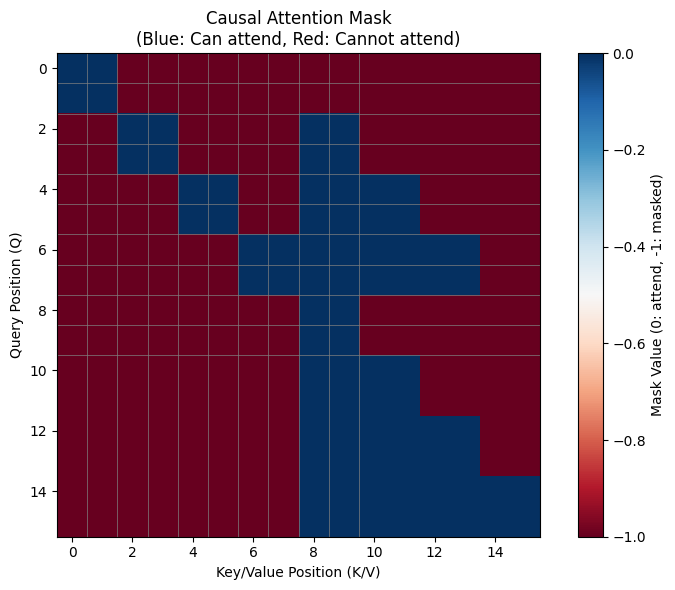

In [74]:
import matplotlib.pyplot as plt
test_mask = build_train_mask(8, 2, torch.device('cpu'))
mask_2d = test_mask.squeeze()
print(mask_2d)

# 시각화를 위해 -inf를 -1로 변환
mask_vis = mask_2d.clone()
mask_vis[mask_vis == float('-inf')] = -1

plt.figure(figsize=(8, 6))
plt.imshow(mask_vis, cmap='RdBu', vmin=-1, vmax=0)
plt.colorbar(label='Mask Value (0: attend, -1: masked)')
plt.xlabel('Key/Value Position (K/V)')
plt.ylabel('Query Position (Q)')
plt.title('Causal Attention Mask\n(Blue: Can attend, Red: Cannot attend)')

# 격자 추가
for i in range(10):
    plt.axhline(i + 0.5, color='gray', linewidth=0.5)
    plt.axvline(i + 0.5, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()


In [8]:
class BD3LM(nn.Module):
    def __init__(self, vocab_size, num_layers, hidden_size, ffn_size, heads, block_size):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.block_size = block_size
        self.mask_token_id = vocab_size

        self.tokenizer = nn.Embedding(vocab_size+1, hidden_size)
        self.timestep_embed = TimeStepEmbedder(hidden_size, hidden_size)
        self.transformer = nn.ModuleList(
            [TransformerBlock(hidden_size, heads, ffn_size) for _ in range(num_layers)]
        )
        self.norm_final = nn.RMSNorm(hidden_size)
        self.head = nn.Linear(hidden_size, vocab_size)

    def forward(self,
                x_t: torch.Tensor,
                t: torch.Tensor,
                kv_cache: list[tuple[torch.Tensor, torch.Tensor]] | None = None,
                attn_mask: torch.Tensor | None = None
                ):
        x = self.tokenizer(x_t) + self.timestep_embed(t).unsqueeze(1)

        present_key_values = []
        for i, layer in enumerate(self.transformer):
            past_kv_for_layer = kv_cache[i] if kv_cache is not None else None
            x, present_kv = layer(x, past_kv=past_kv_for_layer, attn_mask=attn_mask)
            present_key_values.append(present_kv)

        x = self.norm_final(x)
        return self.head(x), present_key_values

    def forward_train(self,
                      x_t: torch.Tensor,
                      t: torch.Tensor,
                      ):
        noise = torch.full(x_t.shape, self.mask_token_id)
        full_sequence = noise + x_t
        x_train = self.tokenizer(full_sequence) + self.timestep_embed(t).unsqueeze(1)


    @torch.no_grad()
    def generate_block(self,
                       kv_cache: list[tuple[torch.Tensor, torch.Tensor]] | None = None,
                       steps: int = 50):
        device = self.tokenizer.weight.device

        noise_block = torch.full((1, self.block_size), self.vocab_size, device=device)
        alphas = get_cosine_schedule(50).to(device)

        # KV 캐시가 추가되는 방식이라, 있다면 끝까지 유지해야 함
        initial_kv_cache = None
        if kv_cache is not None:
            initial_kv_cache = [(k.clone(), v.clone()) for k, v in kv_cache]

        for t in reversed(range(1, steps + 1)):
            time_steps = torch.tensor([t], device=device)
            logits, _ = self.forward(
                x_t=noise_block,
                kv_cache=initial_kv_cache,
                attn_mask=None,
                t = time_steps
            )
            denoised_block = logits.argmax(dim=-1)

            prev_block = q_sample(denoised_block, t-1, alphas, self.vocab_size, device)
            noise_block = prev_block
        # 이걸 효율적으로 할 수 있을까? forward 좀 바꾸면 가능할 수도? 한정적으로 kv 캐시를 추가해서 반환하지 않게 한다면 별도 저장이 필요없을 듯.
        _, final_kv_cache = self.forward(
            x_t=noise_block,
            kv_cache=initial_kv_cache,
            attn_mask=None,
            t=torch.tensor([0], device=device)
        )

        return noise_block, final_kv_cache

In [9]:
VOCAB_SIZE = 1000
HIDDEN_SIZE = 1024
NUM_LAYERS = 2
HEADS = 4
FFN_SIZE = 4096
BLOCK_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = BD3LM(vocab_size=1000, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, heads=HEADS, ffn_size=FFN_SIZE, block_size=BLOCK_SIZE).to(DEVICE)
model.eval()

# --- 시나리오: prefill 상태 ---
print("\n--- 추론 시나리오: 프롬프트가 주어진 경우 ---")

# 1. 주어진 컨텍스트(프롬프트)로 KV 캐시 생성 (Fallback 로직/prefill 처리)
prompt_tokens = torch.randint(0, VOCAB_SIZE - 1, (1, 10), device=DEVICE) # 예시 프롬프트
print(f"프롬프트 토큰 (길이 {prompt_tokens.shape[1]}): {prompt_tokens}")

# 인과 마스크 생성
causal_mask = create_causal_mask(prompt_tokens.shape[1], DEVICE)

# 모델을 포워드하여 KV 캐시만 얻어옴 (logits는 버림)
_, initial_kv_cache = model.forward(
    x_t=prompt_tokens,
    kv_cache=None, # 캐시가 없으므로 None
    t=torch.tensor([0], device=DEVICE),
    attn_mask=causal_mask
)

print(f"생성된 KV 캐시의 구조: {len(initial_kv_cache)} 레이어")
print(f"첫 번째 레이어 K 캐시 shape: {initial_kv_cache[0][0].shape}") # (B, H, N_k, D_h)

# 2. 생성된 KV 캐시를 사용하여 다음 블록 생성
print("\nKV 캐시를 사용하여 다음 블록 생성 시작...")
generated_block, final_kv_cache = model.generate_block(
    kv_cache=initial_kv_cache,
    steps=50
)

print(f"생성된 블록 (길이 {generated_block.shape[1]}): {generated_block}")
print(f"최종 K 캐시 shape: {final_kv_cache[0][0].shape}") # 길이가 10 + 16 = 26이 되어야 함
assert final_kv_cache[0][0].shape[2] == prompt_tokens.shape[1] + BLOCK_SIZE
print("테스트 통과!")


--- 추론 시나리오: 프롬프트가 주어진 경우 ---
프롬프트 토큰 (길이 10): tensor([[ 56, 751, 911, 180, 688, 365, 661, 858, 574, 661]], device='cuda:0')
생성된 KV 캐시의 구조: 2 레이어
첫 번째 레이어 K 캐시 shape: torch.Size([1, 4, 10, 256])

KV 캐시를 사용하여 다음 블록 생성 시작...
생성된 블록 (길이 16): tensor([[901, 709, 953, 463, 475,  86, 508, 901, 492, 901, 332, 508, 309, 207,
         475, 508]], device='cuda:0')
최종 K 캐시 shape: torch.Size([1, 4, 26, 256])
테스트 통과!
